In [2]:
import numpy as np
from datasets import load_from_disk
import matplotlib.pyplot as plt

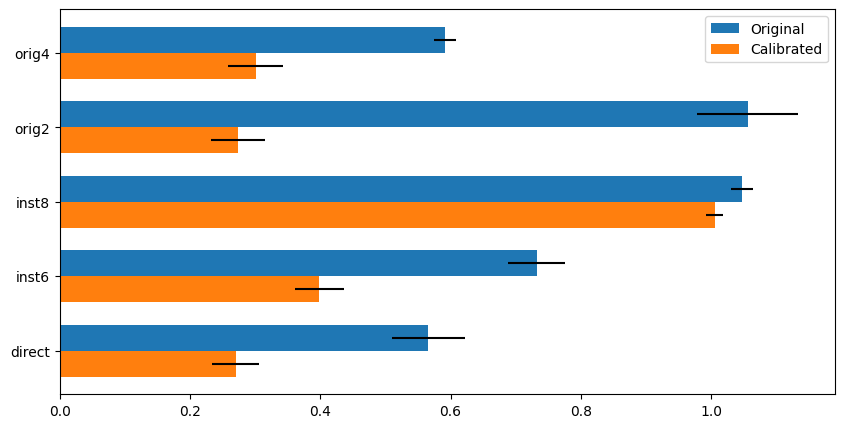

In [4]:


from collections import defaultdict
import os
from typing import Optional, List
from datasets import load_from_disk
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np
from scipy.special import log_softmax


def _compute_metric(logits, targets, metric):
    if metric == "accuracy":
        return accuracy_score(targets, logits.argmax(axis=1))
    elif metric == "error_rate":
        return 1 - accuracy_score(targets, logits.argmax(axis=1))
    elif metric == "f1_score":
        return f1_score(targets, logits.argmax(axis=1), average="macro")
    elif metric == "norm_cross_entropy":
        naive_priors = np.bincount(targets, minlength=logits.shape[1]) / len(targets)
        naive_entropy = - np.mean(np.log(naive_priors[targets]))
        logprobs = log_softmax(logits, axis=1)
        cross_entropy = - np.mean(logprobs[np.arange(len(targets)), targets])
        return cross_entropy / naive_entropy
    else:
        raise ValueError(f"Metric {metric} is not supported")


def compute_metric(logits, targets, metric, bootstrap, random_state):
    if bootstrap == 0:
        return [_compute_metric(logits, targets, metric)]
    
    rs = np.random.RandomState(random_state)
    values = []
    for _ in range(bootstrap):
        idx = rs.choice(len(targets), len(targets), replace=True)
        values.append(_compute_metric(logits[idx], targets[idx], metric))
    return values


def plot_bars(prompts, metric, bootstrap, random_state=0):
    results = defaultdict(list)
    for prompt in prompts:
        original = load_from_disk(f"../experiments/tony_zhao_agnews_{prompt}/tinyllama_3T_bf16/all/validation").flatten().with_format("numpy")
        calibrated = load_from_disk(f"../experiments/tony_zhao_agnews_{prompt}_tinyllama_3T_bf16_logits/affine_vector_model.num_classes=4/all/validation").flatten().with_format("numpy")
        orig_logits = original["output.logits"]
        cal_logits = calibrated["output.logits"]
        labels = original["target"]
        results["orig"].extend(compute_metric(orig_logits, labels, metric, bootstrap, random_state))
        results["cal"].extend(compute_metric(cal_logits, labels, metric, bootstrap, random_state))
        results["prompt"].extend([prompt] * bootstrap)
    df = pd.DataFrame(results).groupby("prompt").agg(["mean", "std"]).reset_index()

    fig, ax = plt.subplots(figsize=(10, 5))
    width = 0.35
    y = np.arange(len(prompts))
    ax.barh(y + width / 2, df["orig"]["mean"], width, label="Original", xerr=df["orig"]["std"])
    ax.barh(y - width / 2, df["cal"]["mean"], width, label="Calibrated", xerr=df["cal"]["std"])
    ax.set_yticks(y)
    ax.set_yticklabels(df["prompt"])
    ax.legend()
    plt.show()




# prompts = [
#     "inst", "inst2", "inst3", "inst4", "inst5", "inst6", "inst7", 
#     "mc", "mcw",
#     "nli", "qa",
#     "orig2", "orig3", "orig4",
#     "paper",
# ]

prompts = [
    "inst8", "orig4", "direct", "inst6", "orig2"
]

plot_bars(prompts, bootstrap=100, metric="norm_cross_entropy", random_state=9287)


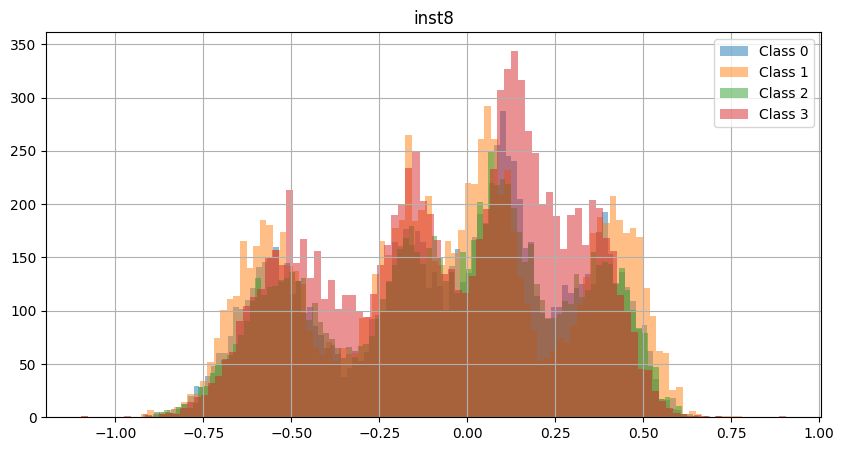

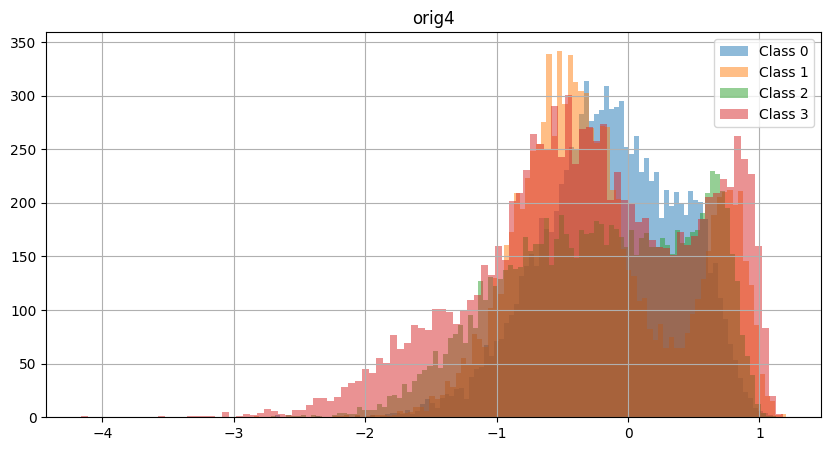

In [44]:
def plot_histograms(prompts):
    for prompt in prompts:
        original = load_from_disk(f"../experiments/tony_zhao_agnews_{prompt}/tinyllama_3T_bf16/all/train").flatten().with_format("numpy")
        
        calibrated = load_from_disk(f"../experiments/tony_zhao_agnews_{prompt}_tinyllama_3T_bf16_logits/affine_vector_model.num_classes=4/all/train").flatten().with_format("numpy")
        logits = original["output.logits"]
        labels = original["target"]
        # logits = calibrated["output.logits"]
        # scores = log_softmax(logits, axis=1)
        # scores = np.exp(log_softmax(logits, axis=1))
        scores = log_softmax(logits, axis=1) - np.log(np.bincount(labels) / len(labels))
        # cal_logits = calibrated["output.logits"]
        
        fig, ax = plt.subplots(figsize=(10, 5))
        for i in range(scores.shape[1]):
            # ax.hist(scores[labels == i, i] - np.log((1 - np.exp(scores[labels == i, i]))), bins=100, alpha=0.5, label=f"Class {i}")
            ax.hist(scores[labels == i, :].flatten(), bins=100, alpha=0.5, label=f"Class {i}")
        ax.set_title(prompt)
        ax.grid(True)
        ax.legend()
        # ax.set_xlim(0, 1000)
        plt.show()

plot_histograms(prompts)

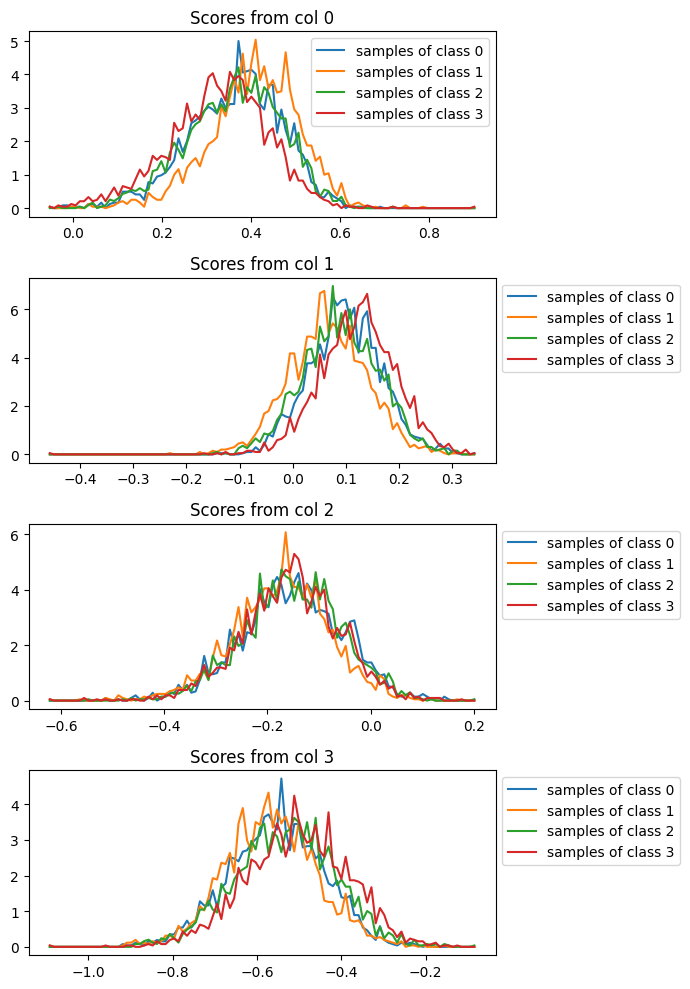

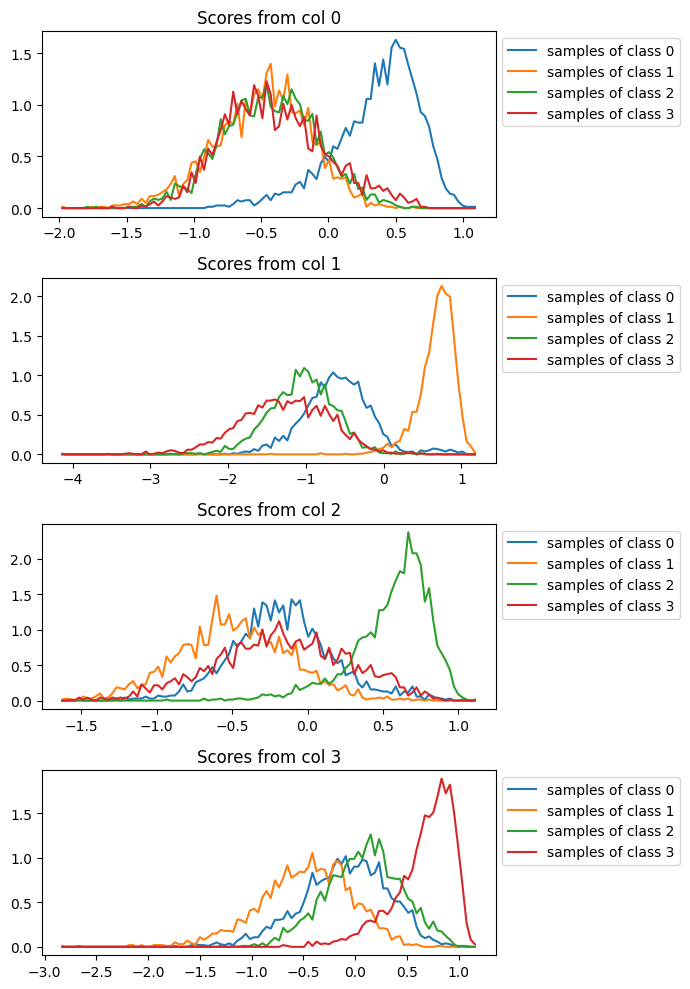

In [52]:
from utils import plot_hists

def my_plot_hists(prompts, original=True, outfile=None, nbins=100, group_by='score', style='-', label_prefix='', axs=None):
    for prompt in prompts:
        if original:
            outputs = load_from_disk(f"../experiments/tony_zhao_agnews_{prompt}/tinyllama_3T_bf16/all/train").flatten().with_format("numpy")
        else:
            outputs = load_from_disk(f"../experiments/tony_zhao_agnews_{prompt}_tinyllama_3T_bf16_logits/affine_vector_model.num_classes=4/all/train").flatten().with_format("numpy")
        targets = outputs["target"]
        # scores = outputs["output.logits"]
        scores = log_softmax(outputs["output.logits"],axis=1) - np.log(np.bincount(targets) / len(targets))
        # scores = log_softmax(outputs["output.logits"],axis=1)
        plot_hists(targets, scores, outfile, nbins, group_by, style, label_prefix, axs)

my_plot_hists(prompts, original=True, outfile=None, nbins=100, group_by='score', style='-', label_prefix='', axs=None)
